In [2]:
import pandas as pd
import numpy as np
import seaborn as sns


In [3]:
df = pd.read_excel(r"C:\Users\DELL\Desktop\course_prac\ml\clustering\EXL Shared Partner Data.xlsx")

In [4]:
df.shape

(458872, 15)

In [5]:
df.head()

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty
2,CUNA11264400,2018-02-09,15000,Signed,42.35,Credit Card,Monthly,2018-02-09,2022-10-09,508.2,508.2,DIR,SI Whole Life,54.0,Liberty
3,CUNA11264436,2018-02-09,15000,Signed,57.05,Credit Card,Monthly,2018-02-09,2022-10-09,684.6,684.6,DIR,SI Whole Life,58.0,Liberty
4,CUNA11264525,2018-02-09,10000,Signed,27.80,ACH/PAC,Monthly,2018-02-12,2021-02-12,333.6,333.6,PAC,SI Term Band 1,65.0,Liberty


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458872 entries, 0 to 458871
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Application_Nr       458862 non-null  object        
 1   QuoteGeneratedDate   458872 non-null  datetime64[ns]
 2   OfferCoverageAmount  458872 non-null  int64         
 3   Offer_Stat_Desc      458872 non-null  object        
 4   OfferPremiumAmount   458872 non-null  float64       
 5   OfferBillingMethod   458872 non-null  object        
 6   Pmnt_Freq_Desc       458832 non-null  object        
 7   Effective_Date       190605 non-null  datetime64[ns]
 8   Paid_To_Date         190605 non-null  datetime64[ns]
 9   Offered_NAP          458872 non-null  float64       
 10  Issued_NAP           190605 non-null  float64       
 11  CurrentBillMethod    190605 non-null  object        
 12  ProductType          458862 non-null  object        
 13  Age_at_AppRece

In [7]:
df.describe()

,QuoteGeneratedDate,OfferCoverageAmount,OfferPremiumAmount,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,Age_at_AppReceived
count,458872,458872.000000,458872.000000,190605,190605,458872.000000,190605.000000,400627.000000
mean,2021-05-29 14:39:36.317578240,41713.013651,75.453247,2021-05-09 20:43:12.611946240,2021-12-18 12:22:37.840559872,891.680556,864.271308,55.467078
min,2018-02-07 00:00:00,1000.000000,0.000000,2018-02-08 00:00:00,2018-02-13 00:00:00,0.000000,0.000000,17.000000
25%,2020-12-02 00:00:00,10000.000000,40.500000,2020-10-17 00:00:00,2021-06-15 00:00:00,485.280000,462.000000,48.000000
50%,2021-07-19 00:00:00,20000.000000,57.300000,2021-06-24 00:00:00,2022-04-01 00:00:00,684.960000,682.680000,58.000000
75%,2022-02-03 00:00:00,45000.000000,90.700000,2022-01-10 00:00:00,2022-09-19 00:00:00,1081.200000,1077.600000,65.000000
max,2022-09-07 00:00:00,300000.000000,5124.000000,2022-11-01 00:00:00,2024-05-01 00:00:00,14496.000000,14496.000000,96.000000
std,NaN,61338.126792,68.232138,NaN,NaN,709.771734,663.639863,13.235514


In [8]:
df.describe(include = 'all')

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
count,458862,458872,458872.000000,458872,458872.000000,458872,458832,190605,190605,458872.000000,190605.000000,190605,458862,400627.000000,458872
unique,458862,NaN,NaN,20,NaN,5,5,NaN,NaN,NaN,NaN,3,5,NaN,9
top,CUNA17318599,NaN,NaN,Signed,NaN,ACH/PAC,Monthly,NaN,NaN,NaN,NaN,DIR,SI Whole Life,NaN,SelectQuote
freq,1,NaN,NaN,165207,NaN,329659,457267,NaN,NaN,NaN,NaN,111804,312810,NaN,228262
mean,NaN,2021-05-29 14:39:36.317578240,41713.013651,NaN,75.453247,NaN,NaN,2021-05-09 20:43:12.611946240,2021-12-18 12:22:37.840559872,891.680556,864.271308,NaN,NaN,55.467078,NaN
min,NaN,2018-02-07 00:00:00,1000.000000,NaN,0.000000,NaN,NaN,2018-02-08 00:00:00,2018-02-13 00:00:00,0.000000,0.000000,NaN,NaN,17.000000,NaN
25%,NaN,2020-12-02 00:00:00,10000.000000,NaN,40.500000,NaN,NaN,2020-10-17 00:00:00,2021-06-15 00:00:00,485.280000,462.000000,NaN,NaN,48.000000,NaN
50%,NaN,2021-07-19 00:00:00,20000.000000,NaN,57.300000,NaN,NaN,2021-06-24 00:00:00,2022-04-01 00:00:00,684.960000,682.680000,NaN,NaN,58.000000,NaN
75%,NaN,2022-02-03 00:00:00,45000.000000,NaN,90.700000,NaN,NaN,2022-01-10 00:00:00,2022-09-19 00:00:00,1081.200000,1077.600000,NaN,NaN,65.000000,NaN
max,NaN,2022-09-07 00:00:00,300000.000000,NaN,5124.000000,NaN,NaN,2022-11-01 00:00:00,2024-05-01 00:00:00,14496.000000,14496.000000,NaN,NaN,96.000000,NaN


In [9]:
from datetime import datetime

df['Quote_Year_Month'] = df['QuoteGeneratedDate'].apply(lambda x: datetime.strftime(x,"%Y-%m"))

In [10]:
df.head()

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,Quote_Year_Month
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty,2018-02
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty,2018-02
2,CUNA11264400,2018-02-09,15000,Signed,42.35,Credit Card,Monthly,2018-02-09,2022-10-09,508.2,508.2,DIR,SI Whole Life,54.0,Liberty,2018-02
3,CUNA11264436,2018-02-09,15000,Signed,57.05,Credit Card,Monthly,2018-02-09,2022-10-09,684.6,684.6,DIR,SI Whole Life,58.0,Liberty,2018-02
4,CUNA11264525,2018-02-09,10000,Signed,27.80,ACH/PAC,Monthly,2018-02-12,2021-02-12,333.6,333.6,PAC,SI Term Band 1,65.0,Liberty,2018-02


In [11]:
df['Quote_Year'] = df['QuoteGeneratedDate'].apply(lambda x: datetime.strftime(x,"%Y"))

In [12]:
df.head()

,Application_Nr,QuoteGeneratedDate,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Effective_Date,Paid_To_Date,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,Quote_Year_Month,Quote_Year
0,CUNA11261506,2018-02-07,15000,Void,13.75,Credit Card,Monthly,NaT,NaT,165.0,NaN,NaN,SI Term Band 1,53.0,Liberty,2018-02,2018
1,CUNA11263501,2018-02-08,10000,Signed,74.80,Credit Card,Monthly,2018-02-08,2022-09-08,897.6,897.6,PAC,SI Whole Life,70.0,Liberty,2018-02,2018
2,CUNA11264400,2018-02-09,15000,Signed,42.35,Credit Card,Monthly,2018-02-09,2022-10-09,508.2,508.2,DIR,SI Whole Life,54.0,Liberty,2018-02,2018
3,CUNA11264436,2018-02-09,15000,Signed,57.05,Credit Card,Monthly,2018-02-09,2022-10-09,684.6,684.6,DIR,SI Whole Life,58.0,Liberty,2018-02,2018
4,CUNA11264525,2018-02-09,10000,Signed,27.80,ACH/PAC,Monthly,2018-02-12,2021-02-12,333.6,333.6,PAC,SI Term Band 1,65.0,Liberty,2018-02,2018


In [13]:
data = df.groupby(['Quote_Year'])['OfferCoverageAmount'].sum().reset_index(name = 'coverage_sum')

In [14]:
data.head()

,Quote_Year,coverage_sum
0,2018,179392000
1,2019,1096232000
2,2020,2505178000
3,2021,7213646000
4,2022,8146486000


In [15]:
data_month = df.groupby(['Quote_Year_Month'])['OfferCoverageAmount'].sum().reset_index(name = 'coverage_sum')

In [16]:
data_month.head()

,Quote_Year_Month,coverage_sum
0,2018-02,3379000
1,2018-03,7988000
2,2018-04,6284000
3,2018-05,6705000
4,2018-06,6586000


In [17]:
data_month.shape

(56, 2)

In [18]:
data

,Quote_Year,coverage_sum
0,2018,179392000
1,2019,1096232000
2,2020,2505178000
3,2021,7213646000
4,2022,8146486000


<Axes: xlabel='Quote_Year_Month', ylabel='coverage_sum'>

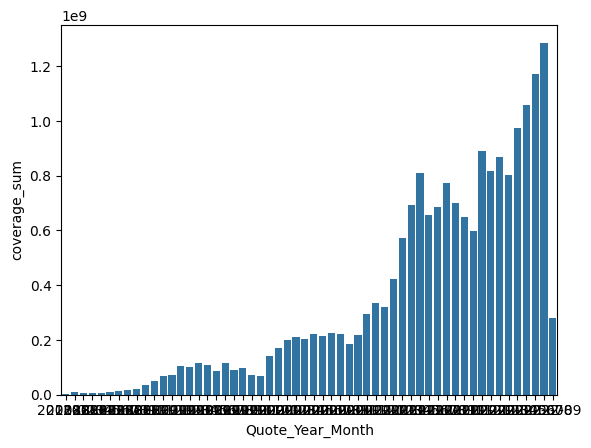

In [19]:
sns.barplot(x = data_month['Quote_Year_Month'],y = data_month['coverage_sum'])

In [20]:
data.shape

(5, 2)

In [21]:
df.isna().sum()

Application_Nr             10
QuoteGeneratedDate          0
OfferCoverageAmount         0
Offer_Stat_Desc             0
OfferPremiumAmount          0
OfferBillingMethod          0
Pmnt_Freq_Desc             40
Effective_Date         268267
Paid_To_Date           268267
Offered_NAP                 0
Issued_NAP             268267
CurrentBillMethod      268267
ProductType                10
Age_at_AppReceived      58245
PartnerMarker               0
Quote_Year_Month            0
Quote_Year                  0
dtype: int64

In [22]:
df = df.dropna(subset = ['Application_Nr'])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458862 entries, 0 to 458871
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Application_Nr       458862 non-null  object        
 1   QuoteGeneratedDate   458862 non-null  datetime64[ns]
 2   OfferCoverageAmount  458862 non-null  int64         
 3   Offer_Stat_Desc      458862 non-null  object        
 4   OfferPremiumAmount   458862 non-null  float64       
 5   OfferBillingMethod   458862 non-null  object        
 6   Pmnt_Freq_Desc       458822 non-null  object        
 7   Effective_Date       190605 non-null  datetime64[ns]
 8   Paid_To_Date         190605 non-null  datetime64[ns]
 9   Offered_NAP          458862 non-null  float64       
 10  Issued_NAP           190605 non-null  float64       
 11  CurrentBillMethod    190605 non-null  object        
 12  ProductType          458852 non-null  object        
 13  Age_at_AppReceived 

In [24]:
df.columns

Index(['Application_Nr', 'QuoteGeneratedDate', 'OfferCoverageAmount',
       'Offer_Stat_Desc', 'OfferPremiumAmount', 'OfferBillingMethod',
       'Pmnt_Freq_Desc', 'Effective_Date', 'Paid_To_Date', 'Offered_NAP',
       'Issued_NAP', 'CurrentBillMethod', 'ProductType', 'Age_at_AppReceived',
       'PartnerMarker', 'Quote_Year_Month', 'Quote_Year'],
      dtype='object')

In [25]:
df['Application_Nr'].value_counts()

Application_Nr
CUNA17318599    1
CUNA11261506    1
CUNA11263501    1
CUNA11264400    1
CUNA11264436    1
               ..
CUNA11268332    1
CUNA11268342    1
CUNA11268400    1
CUNA11268423    1
CUNA11269256    1
Name: count, Length: 458862, dtype: int64

In [26]:
df = df[['OfferCoverageAmount','Offer_Stat_Desc', 'OfferPremiumAmount', 'OfferBillingMethod',
       'Pmnt_Freq_Desc','Offered_NAP','Issued_NAP', 'CurrentBillMethod', 'ProductType', 'Age_at_AppReceived',
       'PartnerMarker']]

In [27]:
df.shape

(458862, 11)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458862 entries, 0 to 458871
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   OfferCoverageAmount  458862 non-null  int64  
 1   Offer_Stat_Desc      458862 non-null  object 
 2   OfferPremiumAmount   458862 non-null  float64
 3   OfferBillingMethod   458862 non-null  object 
 4   Pmnt_Freq_Desc       458822 non-null  object 
 5   Offered_NAP          458862 non-null  float64
 6   Issued_NAP           190605 non-null  float64
 7   CurrentBillMethod    190605 non-null  object 
 8   ProductType          458852 non-null  object 
 9   Age_at_AppReceived   400627 non-null  float64
 10  PartnerMarker        458862 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 42.0+ MB


In [29]:
df.isna().sum()

OfferCoverageAmount         0
Offer_Stat_Desc             0
OfferPremiumAmount          0
OfferBillingMethod          0
Pmnt_Freq_Desc             40
Offered_NAP                 0
Issued_NAP             268257
CurrentBillMethod      268257
ProductType                10
Age_at_AppReceived      58235
PartnerMarker               0
dtype: int64

In [30]:
def null_values(base_dataset):
  print(base_dataset.isna().sum())
  print(len(base_dataset.isna().sum().index))
  cont = base_dataset.describe().columns
  print(cont)

  cat = [i for i in base_dataset.columns if i not in base_dataset.describe().columns] #this is one way of getting categorical column

  print(cat)

  for i in cat:
     base_dataset[i] = base_dataset[i].fillna(base_dataset[i].value_counts().index[0]) # filling null values with help of mode

  for i in cont:
     base_dataset[i] = base_dataset[i].fillna(base_dataset[i].median())
  
  print(base_dataset.isna().sum())
  return base_dataset,cat,cont


In [31]:
data_cleaned,cat,cont = null_values(df)

OfferCoverageAmount         0
Offer_Stat_Desc             0
OfferPremiumAmount          0
OfferBillingMethod          0
Pmnt_Freq_Desc             40
Offered_NAP                 0
Issued_NAP             268257
CurrentBillMethod      268257
ProductType                10
Age_at_AppReceived      58235
PartnerMarker               0
dtype: int64
11
Index(['OfferCoverageAmount', 'OfferPremiumAmount', 'Offered_NAP',
       'Issued_NAP', 'Age_at_AppReceived'],
      dtype='object')
['Offer_Stat_Desc', 'OfferBillingMethod', 'Pmnt_Freq_Desc', 'CurrentBillMethod', 'ProductType', 'PartnerMarker']
OfferCoverageAmount    0
Offer_Stat_Desc        0
OfferPremiumAmount     0
OfferBillingMethod     0
Pmnt_Freq_Desc         0
Offered_NAP            0
Issued_NAP             0
CurrentBillMethod      0
ProductType            0
Age_at_AppReceived     0
PartnerMarker          0
dtype: int64


In [32]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458862 entries, 0 to 458871
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   OfferCoverageAmount  458862 non-null  int64  
 1   Offer_Stat_Desc      458862 non-null  object 
 2   OfferPremiumAmount   458862 non-null  float64
 3   OfferBillingMethod   458862 non-null  object 
 4   Pmnt_Freq_Desc       458862 non-null  object 
 5   Offered_NAP          458862 non-null  float64
 6   Issued_NAP           458862 non-null  float64
 7   CurrentBillMethod    458862 non-null  object 
 8   ProductType          458862 non-null  object 
 9   Age_at_AppReceived   458862 non-null  float64
 10  PartnerMarker        458862 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 42.0+ MB


In [33]:
cat


['Offer_Stat_Desc',
 'OfferBillingMethod',
 'Pmnt_Freq_Desc',
 'CurrentBillMethod',
 'ProductType',
 'PartnerMarker']

In [34]:
cont

Index(['OfferCoverageAmount', 'OfferPremiumAmount', 'Offered_NAP',
       'Issued_NAP', 'Age_at_AppReceived'],
      dtype='object')

In [35]:
from sklearn.preprocessing import LabelEncoder
def label_encoders(data):
  cat_columns = [i for i in data.columns if i not in data.describe().columns]
  le = LabelEncoder()
  for i in cat_columns:
    data[i] = le.fit_transform(data[i])
  return data

In [36]:
data_cleaned['OfferBillingMethod'].unique()

array(['Credit Card', 'ACH/PAC', 'Direct Bill', 'List Bill', 'Unknown'],
      dtype=object)

In [37]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458862 entries, 0 to 458871
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   OfferCoverageAmount  458862 non-null  int64  
 1   Offer_Stat_Desc      458862 non-null  object 
 2   OfferPremiumAmount   458862 non-null  float64
 3   OfferBillingMethod   458862 non-null  object 
 4   Pmnt_Freq_Desc       458862 non-null  object 
 5   Offered_NAP          458862 non-null  float64
 6   Issued_NAP           458862 non-null  float64
 7   CurrentBillMethod    458862 non-null  object 
 8   ProductType          458862 non-null  object 
 9   Age_at_AppReceived   458862 non-null  float64
 10  PartnerMarker        458862 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 42.0+ MB


In [38]:
base_data_label_encoded = label_encoders(data_cleaned)

In [39]:
base_data_label_encoded.head()

,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker
0,15000,17,13.75,1,1,165.0,682.68,1,1,53.0,4
1,10000,14,74.80,1,1,897.6,897.60,2,3,70.0,4
2,15000,14,42.35,1,1,508.2,508.20,1,3,54.0,4
3,15000,14,57.05,1,1,684.6,684.60,1,3,58.0,4
4,10000,14,27.80,0,1,333.6,333.60,2,1,65.0,4


In [40]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3,random_state = 10).fit(base_data_label_encoded)

labels = kmeans.labels_


In [41]:
labels

array([0, 0, 0, ..., 2, 1, 0], shape=(458862,), dtype=int32)

In [77]:

from sklearn.cluster import KMeans



kmeans = KMeans(n_clusters = 10,random_state = 10).fit(base_data_label_encoded)

labels = kmeans.labels_


In [78]:
labels

array([0, 6, 0, ..., 7, 8, 4], shape=(458862,), dtype=int32)

In [79]:
val = pd.DataFrame(data = labels,columns = ['sample'])

In [80]:
val['sample'].value_counts()

sample
6    166365
0     98432
4     69953
5     46180
3     29434
8     13174
2     12272
1     11264
9      6656
7      5132
Name: count, dtype: int64

In [81]:
base_data_label_encoded['cluster'] = labels


In [82]:
base_data_label_encoded['cluster'].value_counts()

cluster
6    166365
0     98432
4     69953
5     46180
3     29434
8     13174
2     12272
1     11264
9      6656
7      5132
Name: count, dtype: int64

In [83]:
base_data_label_encoded.head()

,OfferCoverageAmount,Offer_Stat_Desc,OfferPremiumAmount,OfferBillingMethod,Pmnt_Freq_Desc,Offered_NAP,Issued_NAP,CurrentBillMethod,ProductType,Age_at_AppReceived,PartnerMarker,cluster
0,15000,17,13.75,1,1,165.0,682.68,1,1,53.0,4,0
1,10000,14,74.80,1,1,897.6,897.60,2,3,70.0,4,6
2,15000,14,42.35,1,1,508.2,508.20,1,3,54.0,4,0
3,15000,14,57.05,1,1,684.6,684.60,1,3,58.0,4,0
4,10000,14,27.80,0,1,333.6,333.60,2,1,65.0,4,6


In [84]:
wcss = []

for i in range(2,10):
  kmeans = KMeans(n_clusters = i,init = 'k-means++',random_state=10)
  #What is init='k-means++'?
  #It is the centroid initialization method used in K-Means. It selects initial centroids intelligently so that they are well separated, leading to faster convergence and better clustering results compared to random initialization.
  kmeans.fit(base_data_label_encoded)
  wcss.append(kmeans.inertia_)

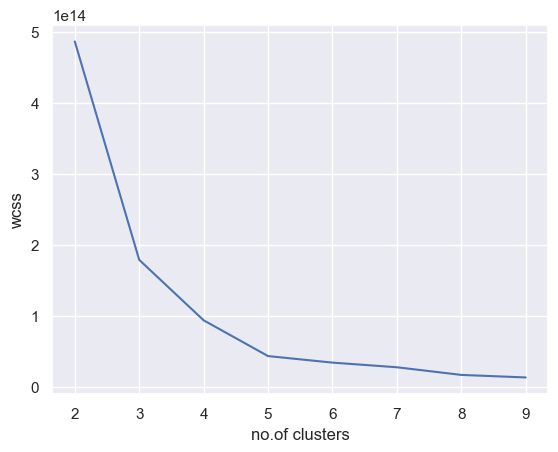

In [85]:
import matplotlib.pyplot as plt

sns.set()
#sns.set() is a Seaborn function used to set the default aesthetic style for plots. It improves the appearance of Matplotlib graphs by applying Seaborn themes such as grids, fonts, and color settings.
plt.plot(range(2,10),wcss)
plt.xlabel("no.of clusters")
plt.ylabel("wcss")
plt.show()

In [51]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2,10):
  kmeans = KMeans(n_clusters = i,init = 'k-means++',random_state=10)
  silhouette_scores.append(silhouette_score(base_data_label_encoded,kmeans.fit_predict(base_data_label_encoded)))


KeyboardInterrupt: 

In [ ]:
plt.bar(range(2,11), silhouette_scores)
plt.xlabel('Number of clusters', fontsize = 20)
plt.ylabel('silhouette_score', fontsize = 20)
plt.show()

In [86]:
X = base_data_label_encoded[['OfferCoverageAmount','OfferPremiumAmount']]

In [87]:
X

,OfferCoverageAmount,OfferPremiumAmount
0,15000,13.75
1,10000,74.80
2,15000,42.35
3,15000,57.05
4,10000,27.80
...,...,...
458867,70000,186.60
458868,300000,68.00
458869,250000,55.00
458870,80000,89.40


In [88]:
X = X.values

In [89]:
X

array([[1.500e+04, 1.375e+01],
       [1.000e+04, 7.480e+01],
       [1.500e+04, 4.235e+01],
       ...,
       [2.500e+05, 5.500e+01],
       [8.000e+04, 8.940e+01],
       [3.000e+04, 2.943e+02]], shape=(458862, 2))

In [90]:
Y = labels

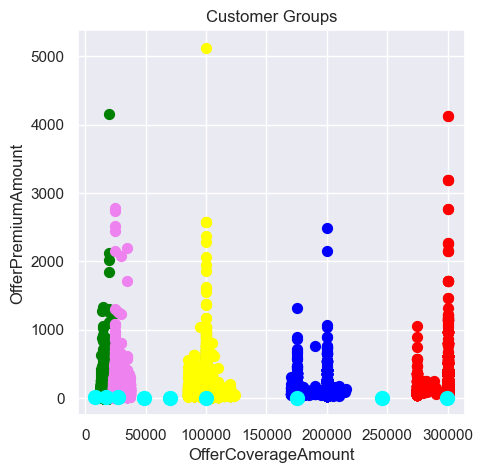

In [91]:
plt.figure(figsize=(5,5))
plt.scatter(X[Y==0,0],X[Y==0,1],s = 50,c = 'green',label = 'cluster1')
plt.scatter(X[Y==1,0],X[Y==1,1],s = 50,c = 'blue',label = 'cluster2')
plt.scatter(X[Y==2,0],X[Y==2,1],s = 50,c = 'red',label = 'cluster3')
plt.scatter(X[Y==3,0],X[Y==3,1],s = 50,c = 'yellow',label = 'cluster4')
plt.scatter(X[Y==4,0],X[Y==4,1],s = 50,c = 'violet',label = 'cluster5')

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='cyan', label='Centroids')

plt.title('Customer Groups')
plt.xlabel('OfferCoverageAmount')
plt.ylabel('OfferPremiumAmount')
plt.show()